# Violation curves

Compare the seed-averaged violation rate throughout training for ZoneEnvComplex and WarehouseEnv.

In [14]:
from pathlib import Path

import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib import pyplot as plt

sns.set_theme(style="darkgrid")

# The notebook may be run from either the repository root or paper/.
project_root = Path.cwd().resolve()
if not (project_root / "runs").is_dir():
    project_root = project_root.parent

METHODS = [
    {
        "Environment": "ZoneEnvComplex",
        "Method": "GenZ-LTL",
        "path": "runs/ZoneEnvComplex/genz_ltl/main/violation_checkpoints.csv",
    },
    {
        "Environment": "ZoneEnvComplex",
        "Method": "StructLTL",
        "path": "runs/ZoneEnvComplex/struct_ltl/main/violation_checkpoints.csv",
    },
    {
        "Environment": "WarehouseEnv",
        "Method": "GenZ-LTL",
        "path": "runs/WarehouseEnv/genz_ltl/main/violation_checkpoints.csv",
    },
    {
        "Environment": "WarehouseEnv",
        "Method": "StructLTL",
        "path": "runs/WarehouseEnv/struct_ltl/main/violation_checkpoints.csv",
    },
]


In [15]:
def load_results(run: dict[str, str]) -> pd.DataFrame:
    """Load a run and average its violation rates across seeds."""
    path = project_root / run["path"]
    if not path.is_file():
        raise FileNotFoundError(f"No violation results for {run['Method']}: {path}")

    df = pd.read_csv(path)
    required_columns = {"timestep", "vr"}
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(f"{path} is missing columns: {sorted(missing_columns)}")

    # New result files contain one seed-averaged row per timestep; this also
    # supports older files that contain one row for each seed.
    return (
        df.groupby("timestep", as_index=False)["vr"].mean()
        .assign(Environment=run["Environment"], Method=run["Method"])
        .sort_values("timestep")
    )


results = pd.concat([load_results(run) for run in METHODS], ignore_index=True)
results


,timestep,vr,Environment,Method
0,0,0.072667,ZoneEnvComplex,GenZ-LTL
1,524288,0.055000,ZoneEnvComplex,GenZ-LTL
2,1048576,0.063667,ZoneEnvComplex,GenZ-LTL
3,1572864,0.052000,ZoneEnvComplex,GenZ-LTL
4,2097152,0.033333,ZoneEnvComplex,GenZ-LTL
...,...,...,...,...
555,192937984,0.031000,WarehouseEnv,StructLTL
556,195035136,0.030333,WarehouseEnv,StructLTL
557,197132288,0.023000,WarehouseEnv,StructLTL
558,199229440,0.041000,WarehouseEnv,StructLTL


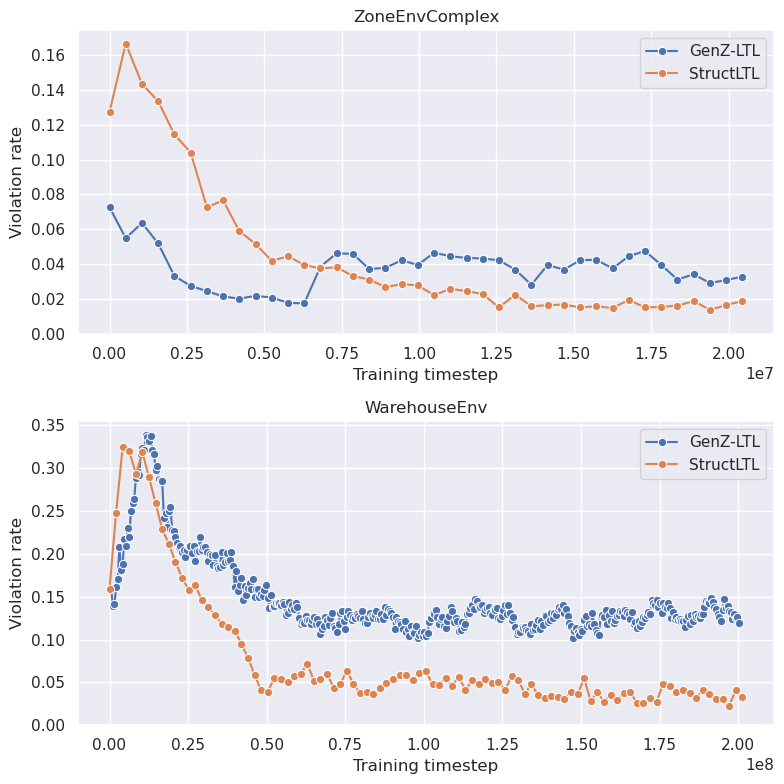

In [16]:
environments = results["Environment"].drop_duplicates().tolist()
fig, axes = plt.subplots(
    len(environments), 1, figsize=(8, 4 * len(environments)), sharex=False
)
axes = [axes] if len(environments) == 1 else axes

for environment, ax in zip(environments, axes, strict=True):
    sns.lineplot(
        data=results.query("Environment == @environment"),
        x="timestep",
        y="vr",
        hue="Method",
        marker="o",
        errorbar=None,
        ax=ax,
    )
    ax.set_title(environment)
    ax.set_xlabel("Training timestep")
    ax.set_ylabel("Violation rate")
    ax.set_ylim(bottom=0)
    ax.legend(title=None)

plt.tight_layout()
plt.show()


## Violation rates at 10% training increments

Each step column is a percentage of that method's training range. The nearest available checkpoint is used for each percentage. The lower violation rate for each environment and step is bolded; ties are bolded for both methods. Environment labels are shown once per pair of methods.

In [20]:
PERCENTAGES = list(range(0, 101, 10))


def sample_at_percentages(df: pd.DataFrame) -> list[float]:
    """Return nearest checkpoint rates at 0%, 10%, ..., 100% training."""
    start, end = df["timestep"].iloc[[0, -1]]
    values = []
    for percentage in PERCENTAGES:
        target = start + (end - start) * percentage / 100
        row = df.iloc[(df["timestep"] - target).abs().argmin()]
        values.append(float(row["vr"]))
    return values


headers = ["Environment", "Method"] + [f"Step {p}%" for p in PERCENTAGES]
table_rows = []
for environment, environment_df in results.groupby("Environment", sort=False):
    sampled_methods = [
        (method, sample_at_percentages(method_df))
        for method, method_df in environment_df.groupby("Method", sort=False)
    ]
    lowest_rates = [min(values[p] for _, values in sampled_methods) for p in range(len(PERCENTAGES))]

    for index, (method, values) in enumerate(sampled_methods):
        formatted_values = []
        for percentage_index, rate in enumerate(values):
            value = f"{rate:.3f}"
            if rate == lowest_rates[percentage_index]:
                value = f"**{value}**"
            formatted_values.append(value)
        table_rows.append([environment if index == 0 else "", method, *formatted_values])

markdown_table = "| " + " | ".join(headers) + " |\n"
markdown_table += "| " + " | ".join(["---"] * len(headers)) + " |\n"
markdown_table += "\n".join("| " + " | ".join(row) + " |" for row in table_rows)
display(Markdown(markdown_table))
print(markdown_table)


| Environment | Method | Step 0% | Step 10% | Step 20% | Step 30% | Step 40% | Step 50% | Step 60% | Step 70% | Step 80% | Step 90% | Step 100% |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ZoneEnvComplex | GenZ-LTL | **0.073** | **0.033** | **0.020** | **0.018** | 0.037 | 0.040 | 0.043 | 0.040 | 0.038 | 0.031 | 0.033 |
|  | StructLTL | 0.127 | 0.114 | 0.059 | 0.040 | **0.031** | **0.028** | **0.023** | **0.017** | **0.015** | **0.016** | **0.019** |
| WarehouseEnv | GenZ-LTL | 0.160 | 0.228 | 0.162 | 0.125 | 0.133 | 0.109 | 0.137 | 0.123 | 0.119 | 0.126 | 0.119 |
|  | StructLTL | **0.159** | **0.190** | **0.110** | **0.059** | **0.038** | **0.063** | **0.049** | **0.034** | **0.029** | **0.039** | **0.033** |

| Environment | Method | Step 0% | Step 10% | Step 20% | Step 30% | Step 40% | Step 50% | Step 60% | Step 70% | Step 80% | Step 90% | Step 100% |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ZoneEnvComplex | GenZ-LTL | **0.073** | **0.033** | **0.020** | **0.018** | 0.037 | 0.040 | 0.043 | 0.040 | 0.038 | 0.031 | 0.033 |
|  | StructLTL | 0.127 | 0.114 | 0.059 | 0.040 | **0.031** | **0.028** | **0.023** | **0.017** | **0.015** | **0.016** | **0.019** |
| WarehouseEnv | GenZ-LTL | 0.160 | 0.228 | 0.162 | 0.125 | 0.133 | 0.109 | 0.137 | 0.123 | 0.119 | 0.126 | 0.119 |
|  | StructLTL | **0.159** | **0.190** | **0.110** | **0.059** | **0.038** | **0.063** | **0.049** | **0.034** | **0.029** | **0.039** | **0.033** |
